---
authors: Freek Pols
updated: December 3, 2025
---

# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [26]:
#Data inladen
data = np.loadtxt('tempmetingen-4cf186212764ab8cff768190b1cc613a.csv', delimiter=';', skiprows=1)
time = data[:, 0] 
temp = data[:, 1]

#Constanten
m_beaker = 820.8        
m_start_total = 1292.9  
m_end_total = 1274.9  
c_water = 4.18 # J/(g*K)
L_vapor = 2260 # J/g     


In [27]:
#Berekeningen voor de massa's en berekening van de theoretische temperatuur
m_water_start = m_start_total - m_beaker
m_evaporated = m_start_total - m_end_total
m_water_avg = m_water_start - (m_evaporated / 2) 

print(f"Water mass start: {m_water_start:.1f} g")
print(f"Water evaporated: {m_evaporated:.1f} g")

P_element = 3000 
T_start = temp[0]
temp_theoretical = T_start + (P_element * time) / (m_water_start * c_water)

Water mass start: 472.1 g
Water evaporated: 18.0 g


In [28]:
#Berekeningen voor de wartmeverliezen Q
dt_total = time[-1] - time[0] 
Q_in = P_element * dt_total
delta_T = temp[-1] - temp[0]
Q_heating = m_water_avg * c_water * delta_T
Q_evap = m_evaporated * L_vapor
Q_out = Q_heating + Q_evap


print(f"Toegevoegde energie (Q_in):   {Q_in:.0f} J")
print(f"Energie voor opwarming (Q_heat):     {Q_heating:.0f} J")
print(f"Energie voor verdamping (Q_evap):    {Q_evap:.0f} J")
print(f"Totaal verklaarde energie (Q_out):   {Q_out:.0f} J")
print(f"Verschil (Verlies):      {Q_in - Q_out:.0f} J")

percentage_accounted = (Q_out / Q_in) * 100
print(f"\nPercentage van energie verklaard: {percentage_accounted:.1f}%")

if 90 < percentage_accounted < 110:
    print("Conclusie: De energiebalans klopt redelijk goed.")
else:
    print("Conclusie: Er is een significant verschil verklaard door warmteverlies naar omgeving.")

Toegevoegde energie (Q_in):   180000 J
Energie voor opwarming (Q_heat):     107241 J
Energie voor verdamping (Q_evap):    40680 J
Totaal verklaarde energie (Q_out):   147921 J
Verschil (Verlies):      32079 J

Percentage van energie verklaard: 82.2%
Conclusie: Er is een significant verschil verklaard door warmteverlies naar omgeving.


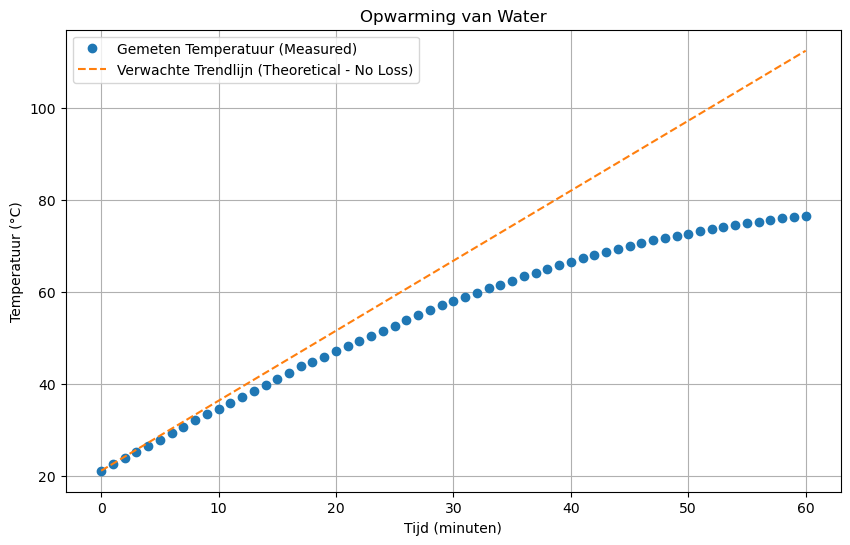

In [29]:
#plot
plt.figure(figsize=(10, 6))
plt.plot(time, temp, 'o', label='Gemeten Temperatuur (Measured)')
plt.plot(time, temp_theoretical, '--', label='Verwachte Trendlijn (Theoretical - No Loss)')
plt.xlabel('Tijd (minuten)')
plt.ylabel('Temperatuur (°C)')
plt.title('Opwarming van Water')
plt.legend()
plt.grid(True)
plt.show()

**Vraag 2** 

In de berekeningen (code hierboven) hebben we de volgende aannames gemaakt:
De kracht van het verwarmingselement is constant en gelijk aan 3KW.
De temperatuur van het water is uniform/goed gemengd.
Alle verloren energie gaat verloren aan verdamping van water.

**Vraag 3** 

Het experiment zou verbeterd kunnen worden door de beker te isoleren - dit zou warmteverlies naar de omgeving vermindderen. Daarnaast zou het gebruik van een nauwkeuriger meetinstrument voor de temperatuurmeting de resultaten kunnen verbeteren. Het toevoegen van een manier om de hoeveelheid verdampte water direct te meten, zoals een weegschaal onder de beker, zou ook nuttig zijn om de resultaten na te kijken (verklaard hoeveel water is verdampt op elk moment). Misschien zou een druk meting van de lucht boven de beker ook kunnen.